# MASCOTS Counterfactual Explanations — FordA

This notebook demonstrates the **MASCOTS** (Model-Agnostic Symbolic COunterfactual explanations for Time Series) algorithm on the **FordA** dataset (univariate, binary classification) using the pretrained SimpleCNN model.

We compare two configurations:

| Variant | Key difference |
|---------|----------------|
| `mascots_scalar` | Default — `swap_method="scalar"`, `n_restarts=3` |
| `mascots_topk10` | `swap_method="scalar"`, `select_top_k=10` — broader swap candidates |

**References**
- Płudowski, D., Spinnato, F., Wilczyński, P., Kotowski, K., Ntagiou, E. V., Guidotti, R., & Biecek, P. (2025). *MASCOTS: Model-Agnostic Symbolic COunterfactual explanations for Time Series.* arXiv:2503.22389.
- GitHub: https://github.com/DawidPludowski/borf

In [1]:
from __future__ import annotations

import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_mascots import mascots_cf
from cfts.metrics import (
    autocorrelation_preservation,
    dtw_distance,
    evaluate_keane_metrics,
    feature_range_validity,
    l2_distance,
    normalized_distance,
    percentage_changed_points,
    prediction_change,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    """Return raw logits as (n_classes,) numpy array."""
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        ts = ts.reshape(1, ts.shape[0], ts.shape[1]) if ts.shape[0] <= ts.shape[1] else ts.T.unsqueeze(0)
    elif ts.ndim == 3:
        if ts.shape[0] != 1:
            ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    if arr.ndim == 3:
        return arr[0]
    raise ValueError(f"Unsupported shape: {arr.shape}")


# Evaluate model on test set
y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth
Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9220


In [3]:
# Build background / training data for the BorfExplainer surrogate
# mascots_cf expects `dataset` as a sequence of (x, y) pairs or an (N, C, L) array

BG_SIZE = min(300, len(dataset_train))

X_bg = np.stack(
    [np.asarray(dataset_train[i][0], dtype=np.float32) for i in range(BG_SIZE)], axis=0
)  # (N, 1, L)
y_bg_onehot = np.stack(
    [np.asarray(dataset_train[i][1], dtype=np.float32) for i in range(BG_SIZE)], axis=0
)  # (N, n_classes)
y_bg_int = np.argmax(y_bg_onehot, axis=1)  # (N,)

# mascots_cf accepts list-of-(x,y) pairs
background_dataset = list(zip(X_bg, y_bg_int))

# Reference data for feature_range_validity metric
reference_data = X_bg

print(f"Background data: {X_bg.shape}, labels: {y_bg_int.shape}")
print(f"Label distribution: {np.unique(y_bg_int, return_counts=True)}")

Background data: (300, 1, 500), labels: (300,)
Label distribution: (array([0, 1]), array([157, 143]))


Sample shape : (1, 500)
True label   : 0
Predicted    : 0  (scores: [9.9999988e-01 1.6135729e-07])
[mascots_cf] building BorfExplainer on N=300 samples …
[mascots_cf] surrogate metrics: {'accuracy': np.float64(0.97)}
[mascots_cf] done – original=0  cf=0  p_target=0.376

CF predicted : 0  (scores: [0.75269485 0.24730512])
CF shape     : (1, 500)


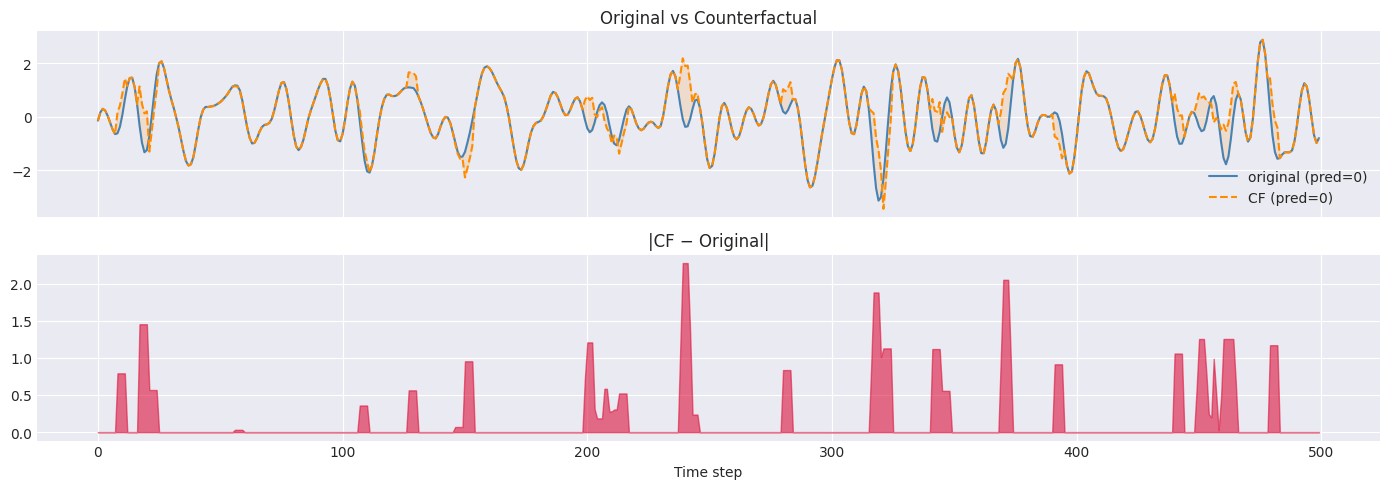

In [4]:
# --- Quick single-sample walkthrough ---
sample_raw, label_raw = dataset_test[0]
sample_raw = np.asarray(sample_raw, dtype=np.float32)
scores_orig = predict_scores(model, sample_raw, device)
pred_orig = int(np.argmax(scores_orig))
true_label = to_class_index(label_raw)

print(f"Sample shape : {sample_raw.shape}")
print(f"True label   : {true_label}")
print(f"Predicted    : {pred_orig}  (scores: {scores_orig})")

cf, cf_scores = mascots_cf(
    sample=sample_raw,
    model=model,
    dataset=background_dataset,
    max_iter=100,
    swap_method="scalar",
    n_restarts=3,
    C=0.1,
    select_top_k=5,
    seed=42,
    verbose=True,
)

cf_pred = int(np.argmax(cf_scores))
print(f"\nCF predicted : {cf_pred}  (scores: {cf_scores})")
print(f"CF shape     : {np.asarray(cf).shape}")

# Quick plot
x_1d = to_channel_first(sample_raw)[0]
cf_1d = to_channel_first(cf)[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(x_1d, color="steelblue", linewidth=1.5, label=f"original (pred={pred_orig})")
axes[0].plot(cf_1d, color="darkorange", linewidth=1.5, linestyle="--", label=f"CF (pred={cf_pred})")
axes[0].fill_between(np.arange(len(x_1d)), x_1d, cf_1d, alpha=0.15, color="darkorange")
axes[0].set_title("Original vs Counterfactual")
axes[0].legend()
axes[1].fill_between(np.arange(len(x_1d)), 0, np.abs(cf_1d - x_1d), color="crimson", alpha=0.6)
axes[1].set_title("|CF − Original|")
axes[1].set_xlabel("Time step")
plt.tight_layout()
plt.show()

In [5]:
def model_wrapper(ts: np.ndarray) -> np.ndarray:
    """(N, L) or (C, L) → scores array, for metrics helpers."""
    return predict_scores(model, np.asarray(ts, dtype=np.float32), device)


def infer_target_class(scores: np.ndarray) -> int:
    return int(np.argsort(scores)[::-1][1])


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


def compute_metrics(sample_cf, cf_cf, target_class):
    """Quality metrics for (sample, counterfactual) both as (C, L) arrays."""
    keane = evaluate_keane_metrics(
        original_ts_list=sample_cf,
        counterfactual_ts_list=cf_cf,
        model=model_wrapper,
        target_classes=int(target_class),
    )
    return {
        "l2_norm": float(l2_distance(sample_cf, cf_cf)),
        "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
        "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_cf, cf_cf)),
        "range_validity": float(feature_range_validity(cf_cf, reference_data)),
        "autocorr": float(autocorrelation_preservation(sample_cf, cf_cf)),
        "keane_validity": float(keane["validity"]),
        "keane_proximity": float(keane["proximity"]),
        "keane_compactness": float(keane["compactness"]),
        "validity": float(prediction_change(sample_cf, cf_cf, model_wrapper, target_class=target_class)),
    }

In [6]:
N_SAMPLES = 30

selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 30 correctly classified test samples.


In [7]:
METHODS = ["mascots_scalar", "mascots_topk10"]
METHOD_COLORS = ["#2a9d8f", "#264653"]


def run_mascots(sample_raw, target_class, variant: str):
    kwargs = dict(
        sample=sample_raw,
        model=model,
        target_class=target_class,
        dataset=background_dataset,
        max_iter=100,
        swap_method="scalar",
        C=0.1,
        attribution_name="coef",
        seed=42,
        verbose=False,
    )
    if variant == "mascots_scalar":
        kwargs.update(n_restarts=3, select_top_k=5)
    elif variant == "mascots_topk10":
        kwargs.update(n_restarts=3, select_top_k=10)
    else:
        raise ValueError(f"Unknown variant: {variant}")

    cf, scores = mascots_cf(**kwargs)
    return cf, scores

In [8]:
records = []
all_cfs = {}  # {sample_idx: {method: cf_array}}

for i, idx in enumerate(selected_indices):
    sample_raw, label = dataset_test[idx]
    sample_raw = np.asarray(sample_raw, dtype=np.float32)
    scores_orig = predict_scores(model, sample_raw, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = infer_target_class(scores_orig)

    all_cfs[idx] = {"sample": sample_raw, "true_label": true_label, "target_class": target_class}

    base = {
        "sample_idx": idx,
        "true_label": true_label,
        "pred_orig": pred_orig,
        "target_class": target_class,
    }

    for variant in METHODS:
        try:
            cf, cf_scores = run_mascots(sample_raw, target_class, variant)
            cf = np.asarray(cf, dtype=np.float32)
            cf_scores = np.asarray(cf_scores).reshape(-1)
            pred_cf = int(np.argmax(cf_scores))
            success = pred_cf == target_class
            sample_cl = to_channel_first(sample_raw)
            cf_cl = to_channel_first(cf)
            metrics = compute_metrics(sample_cl, cf_cl, target_class)
            records.append({
                **base, "method": variant,
                "pred_cf": pred_cf, "success": bool(success),
                **metrics, "error": None,
            })
            all_cfs[idx][variant] = cf
        except Exception as exc:
            records.append({
                **base, "method": variant,
                "pred_cf": None, "success": False, "error": f"{type(exc).__name__}: {exc}",
            })

    print(f"[{i + 1}/{len(selected_indices)}] Completed sample {idx}")

results_df = pd.DataFrame(records)
print(f"Evaluation complete. Total records: {len(results_df)}")
results_df.head(9)

[1/30] Completed sample 0
[2/30] Completed sample 1
[3/30] Completed sample 2
[4/30] Completed sample 3
[5/30] Completed sample 5
[6/30] Completed sample 6
[7/30] Completed sample 7
[8/30] Completed sample 8
[9/30] Completed sample 9
[10/30] Completed sample 10
[11/30] Completed sample 11
[12/30] Completed sample 12
[13/30] Completed sample 13
[14/30] Completed sample 14
[15/30] Completed sample 15
[16/30] Completed sample 17
[17/30] Completed sample 18
[18/30] Completed sample 19
[19/30] Completed sample 20
[20/30] Completed sample 21
[21/30] Completed sample 22
[22/30] Completed sample 23
[23/30] Completed sample 24
[24/30] Completed sample 25
[25/30] Completed sample 26
[26/30] Completed sample 27
[27/30] Completed sample 28
[28/30] Completed sample 29
[29/30] Completed sample 30
[30/30] Completed sample 31
Evaluation complete. Total records: 60


,sample_idx,true_label,pred_orig,target_class,method,pred_cf,success,l2_norm,dtw_proximity,normalized_distance,sparsity,range_validity,autocorr,keane_validity,keane_proximity,keane_compactness,validity,error
0,0,0,0,1,mascots_scalar,0,False,10.668354,4.489332,0.079201,0.774,0.952,0.974751,0.0,10.668354,0.774,0.0,None
1,0,0,0,1,mascots_topk10,0,False,12.793571,6.337257,0.094979,0.640,0.942,0.974984,0.0,12.793571,0.646,0.0,None
2,1,0,0,1,mascots_scalar,0,False,0.000000,0.000000,0.000000,1.000,0.962,1.000000,0.0,0.000000,1.000,0.0,None
3,1,0,0,1,mascots_topk10,0,False,0.000000,0.000000,0.000000,1.000,0.962,1.000000,0.0,0.000000,1.000,0.0,None
4,2,0,0,1,mascots_scalar,1,True,4.831085,2.454369,0.024963,0.866,0.936,0.999986,1.0,4.831085,0.866,1.0,None
5,2,0,0,1,mascots_topk10,1,True,4.357328,2.127957,0.022515,0.868,0.936,0.999984,1.0,4.357328,0.868,1.0,None
6,3,1,1,0,mascots_scalar,0,True,14.023415,7.388040,0.092381,0.516,0.930,0.999926,1.0,14.023415,0.516,1.0,None
7,3,1,1,0,mascots_topk10,0,True,17.788887,10.184113,0.117187,0.540,0.872,0.999304,1.0,17.788887,0.540,1.0,None
8,5,1,1,0,mascots_scalar,0,True,14.748853,8.977266,0.136839,0.488,0.884,0.999586,1.0,14.748853,0.488,1.0,None


In [9]:
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        validity_mean=("validity", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            normalized_distance_mean=("normalized_distance", "mean"),
            sparsity_mean=("sparsity", "mean"),
            range_validity_mean=("range_validity", "mean"),
            autocorr_mean=("autocorr", "mean"),
            keane_proximity_mean=("keane_proximity", "mean"),
            keane_compactness_mean=("keane_compactness", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)
summary_df["n_successful"] = summary_df["n_successful"].fillna(0).astype(int)

display_cols = [
    "method", "n_successful", "success_rate", "validity_mean",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "range_validity_mean", "autocorr_mean",
    "keane_proximity_mean", "keane_compactness_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,validity_mean,l2_norm_mean,dtw_proximity_mean,sparsity_mean,range_validity_mean,autocorr_mean,keane_proximity_mean,keane_compactness_mean
0,mascots_scalar,15,50.0,0.5000,15.4369,8.3572,0.6192,0.9033,0.9983,15.4369,0.6197
1,mascots_topk10,23,76.7,0.7667,13.3680,7.1998,0.6093,0.9175,0.9972,13.3680,0.6097


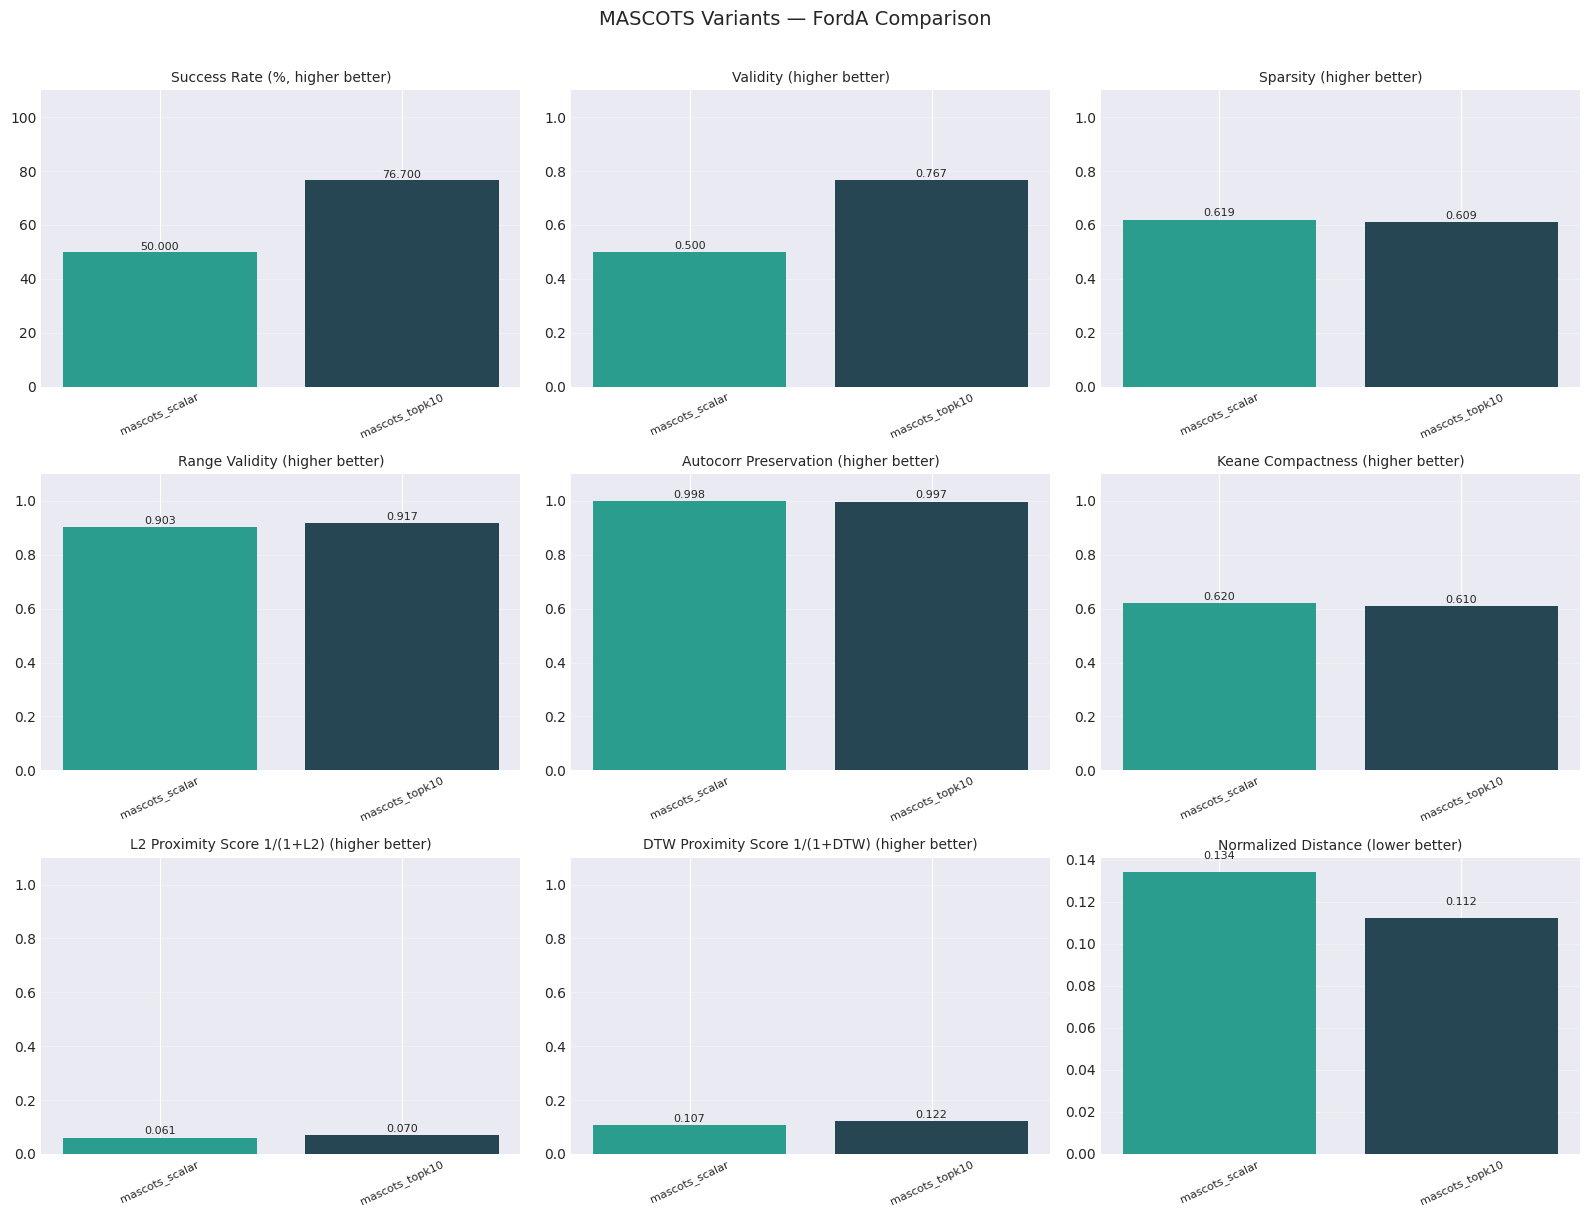

In [10]:
plot_df = summary_df.sort_values("method").reset_index(drop=True)
methods = plot_df["method"].tolist()
colors = METHOD_COLORS[: len(methods)]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
dtw_score = 1.0 / (1.0 + plot_df["dtw_proximity_mean"].fillna(np.inf))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("MASCOTS Variants — FordA Comparison", fontsize=14, y=1.01)

bar(axes[0, 0], plot_df["success_rate"], "Success Rate (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["validity_mean"].fillna(0), "Validity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[1, 0], plot_df["range_validity_mean"].fillna(0), "Range Validity (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], plot_df["autocorr_mean"].fillna(0), "Autocorr Preservation (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["keane_compactness_mean"].fillna(0), "Keane Compactness (higher better)", ylim=(0, 1.1))
bar(axes[2, 0], l2_score, "L2 Proximity Score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[2, 1], dtw_score, "DTW Proximity Score 1/(1+DTW) (higher better)", ylim=(0, 1.1))
bar(axes[2, 2], plot_df["normalized_distance_mean"].fillna(np.nan), "Normalized Distance (lower better)")

plt.tight_layout()
plt.show()

In [11]:
# Pick a sample where all methods succeeded (prefer all-success, fall back to most-success)
success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
)

full_success = [int(si) for si, cnt in success_counts.items() if int(cnt) == len(METHODS)]
rep_idx = full_success[0] if full_success else int(success_counts.index[0])

print(f"Representative sample index: {rep_idx}")
print(f"Methods succeeded: {int(success_counts[rep_idx])} / {len(METHODS)}")

Representative sample index: 17
Methods succeeded: 2 / 2


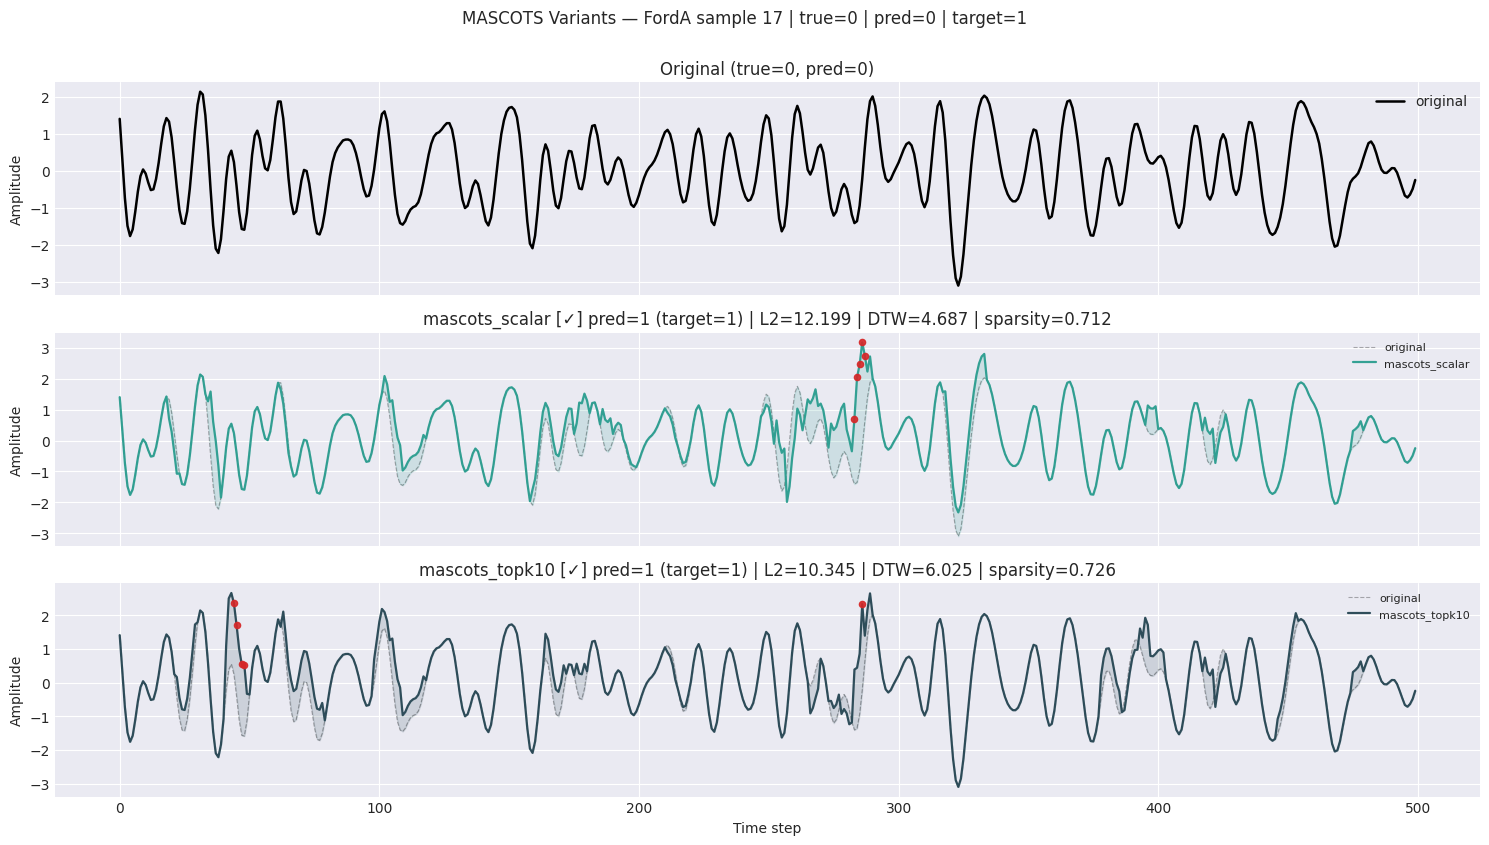

In [12]:
rep = all_cfs[rep_idx]
x_1d = to_channel_first(rep["sample"])[0]
x_axis = np.arange(len(x_1d))

sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred_cf": int(row["pred_cf"]) if pd.notna(row.get("pred_cf")) else None,
        "l2": float(row["l2_norm"]) if pd.notna(row.get("l2_norm")) else np.nan,
        "dtw": float(row["dtw_proximity"]) if pd.notna(row.get("dtw_proximity")) else np.nan,
        "sparsity": float(row["sparsity"]) if pd.notna(row.get("sparsity")) else np.nan,
    }
    for _, row in sample_results.iterrows()
}

orig_row = sample_results.iloc[0]
true_label = int(orig_row["true_label"])
pred_orig = int(orig_row["pred_orig"])
target_class = int(orig_row["target_class"])

n_rows = 1 + len(METHODS)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, 2.8 * n_rows), sharex=True)
fig.suptitle(
    f"MASCOTS Variants — FordA sample {rep_idx} | true={true_label} | pred={pred_orig} | target={target_class}",
    fontsize=12, y=1.001,
)

axes[0].plot(x_1d, color="black", linewidth=1.8, label="original")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig})")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

for i, method_name in enumerate(METHODS, start=1):
    ax = axes[i]
    cf = rep.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred_cf")
    l2_val = info.get("l2", np.nan)
    dtw_val = info.get("dtw", np.nan)
    sp_val = info.get("sparsity", np.nan)

    ax.plot(x_1d, color="black", linewidth=0.8, linestyle="--", alpha=0.3, label="original")
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_1d = to_channel_first(cf)[0]
        ax.plot(cf_1d, linewidth=1.6, alpha=0.95, color=METHOD_COLORS[i - 1], label=method_name)
        ax.fill_between(x_axis, x_1d, cf_1d, color=METHOD_COLORS[i - 1], alpha=0.15)
        diff_abs = np.abs(cf_1d - x_1d)
        top_idx = np.argsort(diff_abs)[-5:]
        ax.scatter(x_axis[top_idx], cf_1d[top_idx], s=20, color="#d62728", alpha=0.9, zorder=4)

    status = "✓" if worked else "✗"
    ax.set_title(
        f"{method_name} [{status}] pred={pred_cf} (target={target_class}) "
        f"| L2={l2_val:.3f} | DTW={dtw_val:.3f} | sparsity={sp_val:.3f}"
    )
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

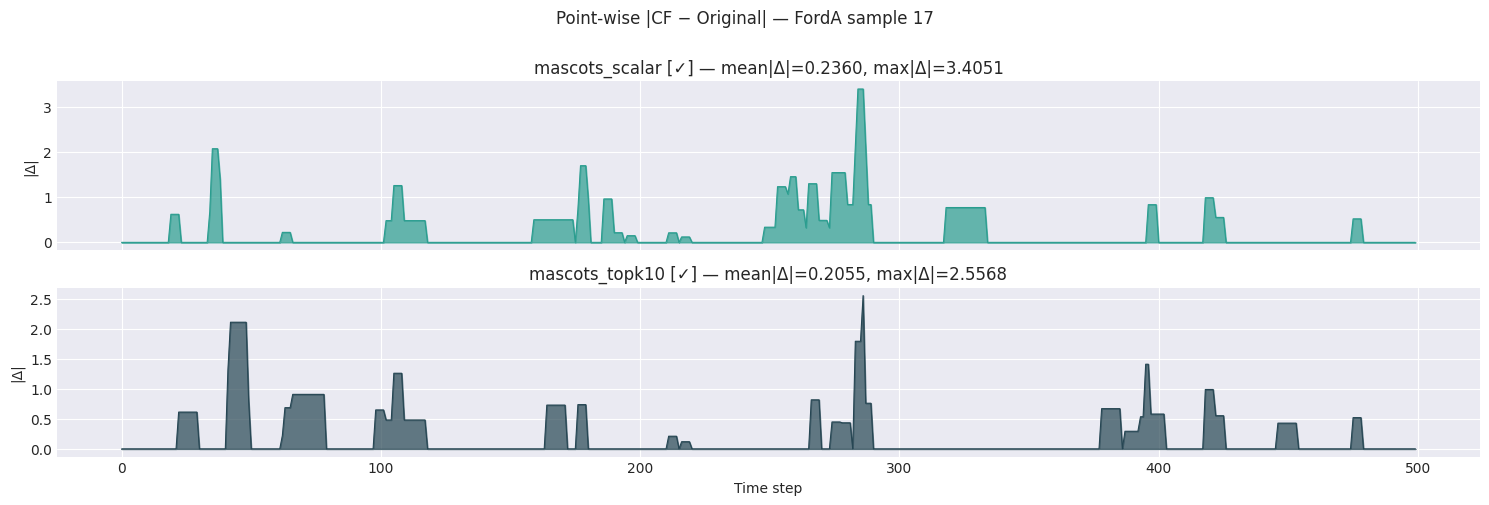

In [13]:
# Point-wise |CF − original| for each method
fig, axes = plt.subplots(len(METHODS), 1, figsize=(15, 2.5 * len(METHODS)), sharex=True)
fig.suptitle(f"Point-wise |CF − Original| — FordA sample {rep_idx}", fontsize=12, y=1.001)

for i, method_name in enumerate(METHODS):
    ax = axes[i]
    cf = rep.get(method_name)
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(method_name)
        continue
    diff = np.abs(to_channel_first(cf)[0] - x_1d)
    info = info_lookup.get(method_name, {})
    status = "✓" if info.get("success", False) else "✗"
    ax.fill_between(x_axis, 0, diff, color=METHOD_COLORS[i], alpha=0.7)
    ax.plot(diff, color=METHOD_COLORS[i], linewidth=0.8)
    ax.set_title(f"{method_name} [{status}] — mean|Δ|={diff.mean():.4f}, max|Δ|={diff.max():.4f}")
    ax.set_ylabel("|Δ|")

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

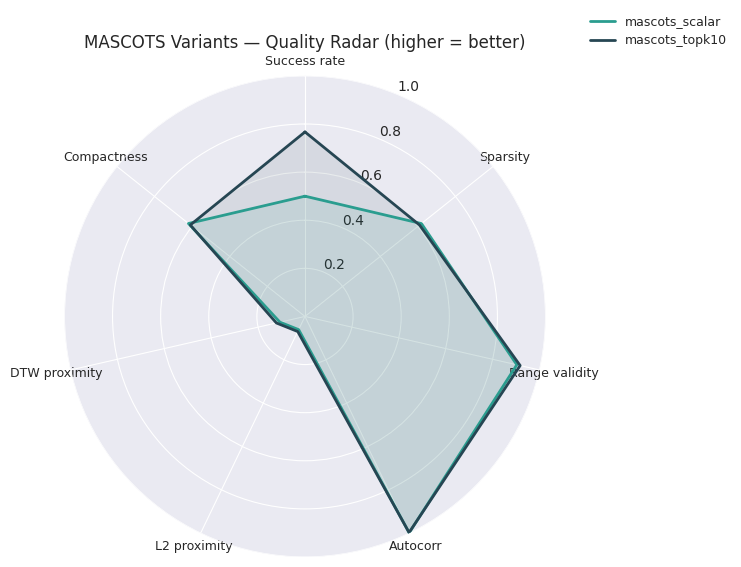

In [14]:
# Radar chart summarising key metrics (all normalised so higher = better)
radar_metrics = [
    "success_rate_norm", "sparsity_mean", "range_validity_mean",
    "autocorr_mean", "l2_score", "dtw_score", "keane_compactness_mean",
]
radar_labels = [
    "Success rate", "Sparsity", "Range validity",
    "Autocorr", "L2 proximity", "DTW proximity", "Compactness",
]

plot_df2 = plot_df.copy()
plot_df2["success_rate_norm"] = plot_df2["success_rate"] / 100.0
plot_df2["l2_score"] = 1.0 / (1.0 + plot_df2["l2_norm_mean"].fillna(np.inf))
plot_df2["dtw_score"] = 1.0 / (1.0 + plot_df2["dtw_proximity_mean"].fillna(np.inf))

N_ax = len(radar_metrics)
angles = [n / float(N_ax) * 2 * np.pi for n in range(N_ax)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=9)
ax.set_ylim(0, 1)

for row_i, row in plot_df2.iterrows():
    vals = [float(row.get(m, 0) or 0) for m in radar_metrics]
    vals += vals[:1]
    color = METHOD_COLORS[row_i % len(METHOD_COLORS)]
    ax.plot(angles, vals, linewidth=2, linestyle="solid", label=row["method"], color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_title("MASCOTS Variants — Quality Radar (higher = better)", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.
